# Proyecto Final AutoTec – Nivel Táctico

## Objetivo del análisis

El objetivo de este notebook es construir indicadores tácticos para apoyar la estimación del precio de mercado de vehículos usados.

El análisis utiliza la base actualizada `autos1.csv`, considerando variables como precio, kilometraje, marca, modelo, año, combustible, tipo de marca, categoría de precio y uso anual estimado.

A partir de estos datos se busca entregar información útil para apoyar decisiones de valorización, segmentación comercial y análisis del comportamiento del mercado automotriz.etivos..

## KPI's Proyecto

| Nivel | Objetivo | Frecuencia | Datos | KPI |
|---|---|---|---|---|
| Táctico | Evaluar cómo cambia el valor de mercado según el nivel de uso del vehículo | Mensual | precio, kilometraje, rango_kilometraje | Variación porcentual del precio promedio entre rangos de kilometraje |
| Táctico | Analizar el impacto de la marca en la valorización de vehículos usados | Mensual | precio, marca | Precio promedio por marca |
| Táctico | Evaluar diferencias del valor de mercado según tipo de combustible considerando nivel de uso | Trimestral | precio, combustible, kilometraje | Variación del valor de mercado según combustible y nivel de uso |
| Táctico | Validar coherencia entre antigüedad y uso acumulado del vehículo | Trimestral | year, uso_anual_estimado | Uso anual promedio como indicador de coherencia del valor comercial |

In [29]:
# ============================================
# 1. CARGA DE LIBRERÍAS Y DATOS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ruta = "/home/jovyan/work/autotec/final/autos1.csv"

df = pd.read_csv(ruta)

print("Datos cargados correctamente")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.head()

Datos cargados correctamente
Filas: 1685
Columnas: 18


,_id,cat_combustible,categoria_precio,ciudad,combustible,fecha_captura,foto_url,grupo,kilometraje,marca,modelo,precio,rango_kilometraje,tipo_marca,url,uso_anual_estimado,usuario,year
0,6a1c90b4b2f827e18bad5008,0,Medio,araucania,bencina,2026-05-31 19:47:03,NaN,AutoTec,44387.0,changan,Cs55 1.5t Elite 4x2 At 5p,15490000.0,Bajo,generalista,https://automoviles.emol.com/venta/autos/chang...,22193.500000,Luz Azocar,2024
1,6a1c90b4b2f827e18bad4ffc,0,Medio,santiago,bencina,2026-05-31 19:47:03,NaN,AutoTec,75500.0,changan,Cs75,8000000.0,Medio,generalista,https://automoviles.emol.com/venta/autos/chang...,8388.888889,Luz Azocar,2017
2,6a1c90b3b2f827e18bad4f11,0,Medio,araucania,bencina,2026-05-31 19:47:58,NaN,AutoTec,92300.0,changan,Cx70 1.6,7190000.0,Medio,generalista,https://automoviles.emol.com/venta/autos/chang...,11537.500000,Luz Azocar,2018
3,6a1c90b2b2f827e18bad4e9e,0,Medio,santiago,bencina,2026-05-31 19:48:40,NaN,AutoTec,87626.0,chery,Arrizo 1.5,6950000.0,Medio,generalista,https://automoviles.emol.com/venta/autos/chery...,29208.666667,Luz Azocar,2023
4,6a1c90b2b2f827e18bad4ea4,0,Medio,santiago,bencina,2026-05-31 19:47:10,NaN,AutoTec,45050.0,chery,Tiggo 1.5t Glx 4x2 Cvt At 5p,12480000.0,Bajo,generalista,https://automoviles.emol.com/venta/autos/chery...,9010.000000,Luz Azocar,2021


In [30]:
# ============================================
# 2. REVISIÓN GENERAL DEL DATASET
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1685 entries, 0 to 1684
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   _id                 1685 non-null   object 
 1   cat_combustible     1685 non-null   int64  
 2   categoria_precio    1685 non-null   object 
 3   ciudad              1685 non-null   object 
 4   combustible         1685 non-null   object 
 5   fecha_captura       1685 non-null   object 
 6   foto_url            97 non-null     object 
 7   grupo               1685 non-null   object 
 8   kilometraje         1685 non-null   float64
 9   marca               1685 non-null   object 
 10  modelo              1685 non-null   object 
 11  precio              1685 non-null   float64
 12  rango_kilometraje   1685 non-null   object 
 13  tipo_marca          1685 non-null   object 
 14  url                 1685 non-null   object 
 15  uso_anual_estimado  1627 non-null   float64
 16  usuari

In [31]:
# ============================================
# 3. REVISIÓN DE VALORES NULOS
# ============================================

df.isnull().sum()

_id                      0
cat_combustible          0
categoria_precio         0
ciudad                   0
combustible              0
fecha_captura            0
foto_url              1588
grupo                    0
kilometraje              0
marca                    0
modelo                   0
precio                   0
rango_kilometraje        0
tipo_marca               0
url                      0
uso_anual_estimado      58
usuario                  0
year                     0
dtype: int64

In [32]:
# ============================================
# 4. LIMPIEZA DE DATOS
# ============================================

# eliminar columna que no aporta al análisis

df = df.drop(
columns=["foto_url"]
)

# completar uso anual

df["uso_anual_estimado"] = (
df["uso_anual_estimado"]

.fillna(

df["uso_anual_estimado"]

.median()

)

)

# tipos numéricos

cols_num = [

"precio",
"kilometraje",
"year",
"uso_anual_estimado"

]

for c in cols_num:

    df[c] = pd.to_numeric(
        df[c],
        errors="coerce"
    )

# eliminar registros inválidos

df = df.dropna(
subset=[
"precio",
"kilometraje",
"year"
]
)

print("Dataset final:")

print(df.shape)

Dataset final:
(1685, 17)


In [33]:
# ============================================
# 5. RESUMEN GENERAL
# ============================================

resumen = pd.DataFrame({

"Métrica":[

"Cantidad vehículos",

"Precio promedio",

"Kilometraje promedio",

"Marcas",

"Combustibles"

],

"Resultado":[

len(df),

round(df["precio"].mean()),

round(df["kilometraje"].mean()),

df["marca"].nunique(),

df["combustible"].nunique()

]

})

resumen

,Métrica,Resultado
0,Cantidad vehículos,1685
1,Precio promedio,15634256
2,Kilometraje promedio,69602
3,Marcas,32
4,Combustibles,3


## Interpretación Inicial

Luego del proceso de limpieza se obtuvo una base consolidada y apta para el análisis táctico del mercado automotriz.

Se eliminaron variables que no aportaban directamente al objetivo del estudio y se trataron valores faltantes para mantener consistencia analítica.

La base final permitirá construir indicadores orientados a estimar el precio de mercado de vehículos usados considerando características asociadas al nivel de uso y atributos comerciales del vehículo.

In [35]:
# ============================================
# KPI 1
# VARIACIÓN DEL PRECIO SEGÚN KILOMETRAJE
# ============================================

kpi1 = (

df

.groupby(
"rango_kilometraje"
)

["precio"]

.mean()

.reset_index()

)

kpi1

,rango_kilometraje,precio
0,Alto,1.202809e+07
1,Bajo,1.738127e+07
2,Medio,1.509089e+07


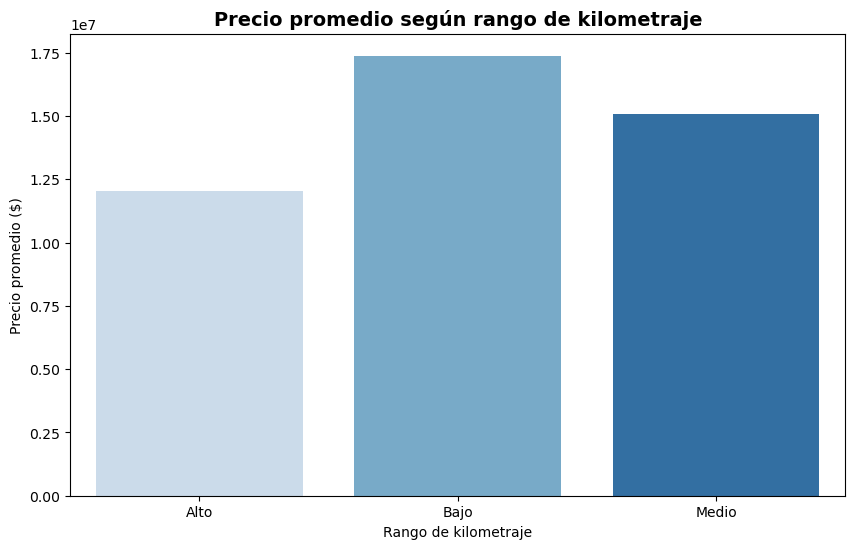

In [36]:
# ============================================
# VISUALIZACIÓN KPI 1
# ============================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=kpi1,
    x="rango_kilometraje",
    y="precio",
    hue="rango_kilometraje",
    palette="Blues",
    legend=False
)

plt.title(
    "Precio promedio según rango de kilometraje",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Rango de kilometraje")
plt.ylabel("Precio promedio ($)")

plt.show()

In [37]:
# ============================================
# KPI NUMÉRICO
# ============================================

precio_bajo = kpi1.loc[
    kpi1["rango_kilometraje"]=="Bajo",
    "precio"
].values[0]

precio_alto = kpi1.loc[
    kpi1["rango_kilometraje"]=="Alto",
    "precio"
].values[0]

variacion = (
    (precio_bajo - precio_alto)
    / precio_bajo
) * 100

print(
    f"Variación de precio entre kilometraje bajo y alto: {variacion:.2f}%"
)

Variación de precio entre kilometraje bajo y alto: 30.80%


## KPI 1 – Precio promedio según nivel de uso

El análisis evidencia una relación directa entre kilometraje y valor comercial de los vehículos.

Los automóviles clasificados en el rango de kilometraje bajo presentan los precios promedio más elevados, mientras que aquellos con mayores niveles de uso muestran una disminución importante de su valor de mercado.

Este comportamiento confirma que el kilometraje continúa siendo uno de los principales factores utilizados para estimar el precio de vehículos usados.

Desde una perspectiva táctica, este indicador permite apoyar procesos de valorización y estimación de precios de mercado basados en evidencia obtenida del conjunto de datos analizado.

## KPI 1 – Variación del precio según nivel de uso

Los resultados muestran una relación consistente entre el nivel de uso del vehículo y su valor de mercado.

Los vehículos clasificados dentro del rango de kilometraje bajo alcanzaron un precio promedio cercano a los $17,4 millones, mientras que aquellos con kilometraje alto registraron valores cercanos a $12,0 millones.

La diferencia observada representa una variación aproximada del 30,8% entre ambos extremos.

Este comportamiento indica que el kilometraje continúa siendo una variable relevante para la estimación del precio de vehículos usados, aunque no explica completamente el valor comercial observado.

Desde una perspectiva táctica, este indicador permite apoyar procesos de valorización y definición de precios basados en evidencia del mercado.


In [40]:
# ============================================
# KPI 2
# PRECIO PROMEDIO POR MARCA
# ============================================

kpi2 = (

df

.groupby(
"marca"
)

["precio"]

.mean()

.sort_values(
ascending=False
)

.head(10)

.reset_index()

)

kpi2

,marca,precio
0,ford,2.513740e+07
1,subaru,2.121656e+07
2,mazda,2.019889e+07
3,toyota,2.009613e+07
4,jeep,1.753688e+07
5,mitsubishi,1.664257e+07
6,honda,1.658444e+07
7,skoda,1.620818e+07
8,dodge,1.588364e+07
9,great,1.554333e+07


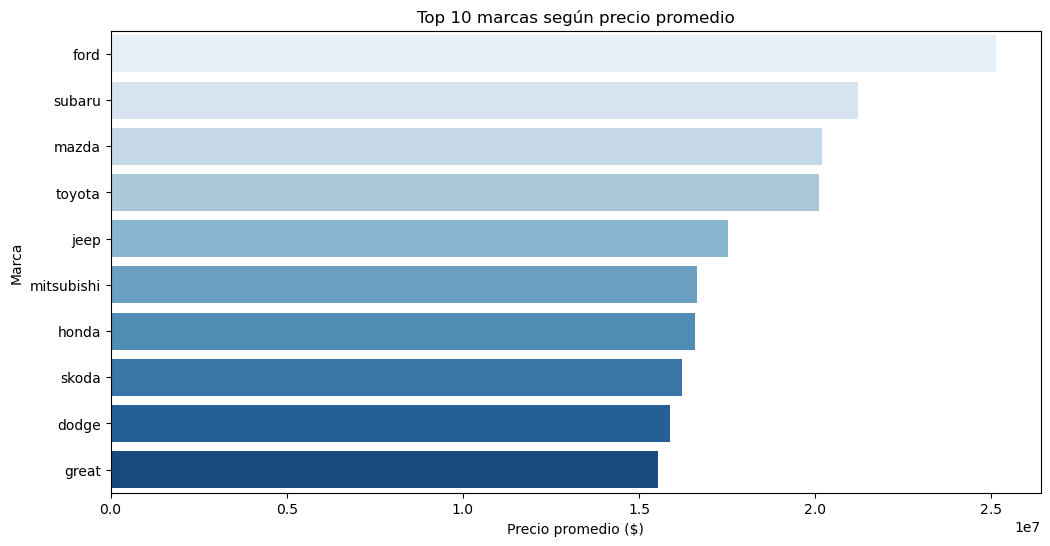

In [41]:
plt.figure(
figsize=(12,6)
)

sns.barplot(

data=kpi2,

x="precio",

y="marca",

hue="marca",

palette="Blues",

legend=False

)

plt.title(
"Top 10 marcas según precio promedio"
)

plt.xlabel(
"Precio promedio ($)"
)

plt.ylabel(
"Marca"
)

plt.show()

## KPI 2 – Precio promedio según marca

El análisis evidencia diferencias relevantes entre fabricantes respecto al valor promedio de comercialización.

Las marcas con mayores precios promedio concentran vehículos pertenecientes a segmentos de mayor valorización dentro del mercado observado.

Los resultados muestran que el precio de un vehículo usado no depende únicamente del kilometraje, sino también del posicionamiento comercial y características asociadas a cada fabricante.

Desde una perspectiva táctica, este indicador permite apoyar procesos de estimación de precios utilizando referencias reales del comportamiento del mercado.


In [43]:
# ============================================
# KPI 3
# PRECIO POR COMBUSTIBLE Y KILOMETRAJE
# ============================================

kpi3 = (

df

.groupby(
[
"combustible",
"rango_kilometraje"
]

)

["precio"]

.mean()

.reset_index()

)

kpi3

,combustible,rango_kilometraje,precio
0,bencina,Alto,1.171707e+07
1,bencina,Bajo,1.676388e+07
2,bencina,Medio,1.444694e+07
3,diesel,Alto,1.236964e+07
4,diesel,Bajo,2.053482e+07
5,diesel,Medio,1.692273e+07
6,hibrido,Bajo,2.374000e+07
7,hibrido,Medio,1.799000e+07


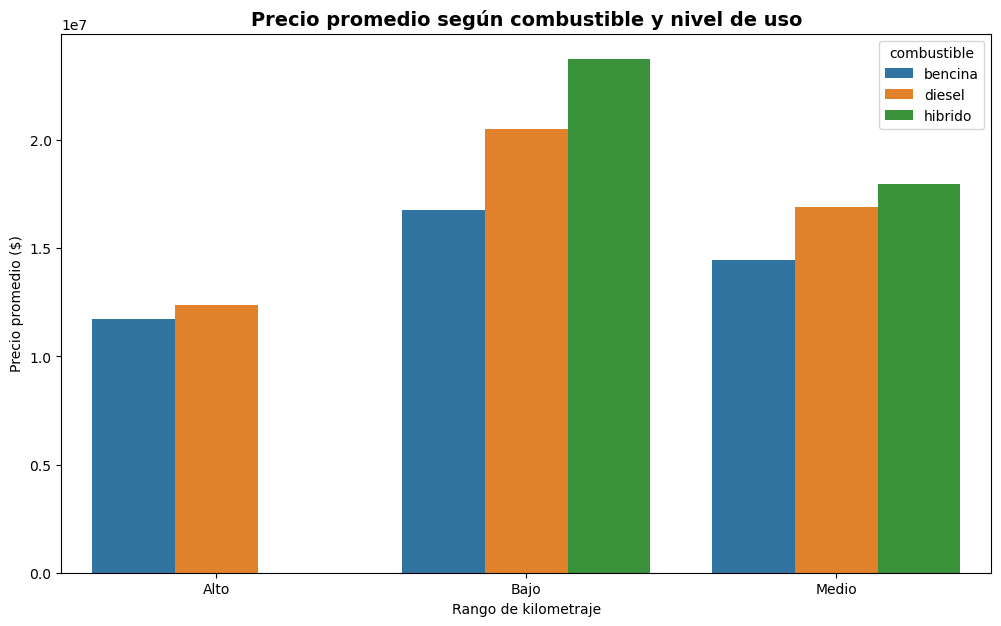

In [44]:
plt.figure(
figsize=(12,7)
)

sns.barplot(

data=kpi3,

x="rango_kilometraje",

y="precio",

hue="combustible"

)

plt.title(
"Precio promedio según combustible y nivel de uso",
fontsize=14,
fontweight="bold"
)

plt.xlabel(
"Rango de kilometraje"
)

plt.ylabel(
"Precio promedio ($)"
)

plt.show()

## KPI 3 – Precio según combustible y nivel de uso

Los resultados permiten observar cómo el tipo de combustible modifica el comportamiento del precio dentro de distintos niveles de uso del vehículo.

Se identifican diferencias de valorización entre tecnologías de motorización incluso cuando los vehículos presentan niveles similares de kilometraje.

Esto evidencia que el valor de mercado no depende exclusivamente del desgaste acumulado, sino también del tipo de tecnología utilizada por el vehículo.

Desde una perspectiva táctica, este indicador permite mejorar procesos de estimación de precios incorporando variables asociadas al perfil técnico del automóvil.


## KPI 3 – Precio promedio según combustible y nivel de uso

El análisis evidencia que el tipo de combustible influye directamente en el valor de mercado de los vehículos usados incluso cuando presentan niveles similares de uso.

Los vehículos híbridos registran los precios promedio más altos dentro del conjunto analizado, especialmente en rangos de kilometraje bajos, mientras que los vehículos a bencina presentan valores promedio inferiores.

Adicionalmente, se observa una disminución del precio a medida que aumenta el kilometraje independientemente del combustible utilizado.

Estos resultados sugieren que el mercado no valora únicamente el nivel de desgaste del vehículo, sino también atributos tecnológicos asociados al sistema de motorización.

Desde una perspectiva táctica, este indicador permite complementar procesos de estimación de precios incorporando variables que afectan directamente la percepción de valor del mercado.


In [45]:
# ============================================
# KPI 4
# USO ANUAL ESTIMADO
# ============================================

kpi4 = (

df

.groupby(
"rango_kilometraje"
)

["uso_anual_estimado"]

.mean()

.reset_index()

)

kpi4

,rango_kilometraje,uso_anual_estimado
0,Alto,23628.931614
1,Bajo,14529.644967
2,Medio,19141.795580


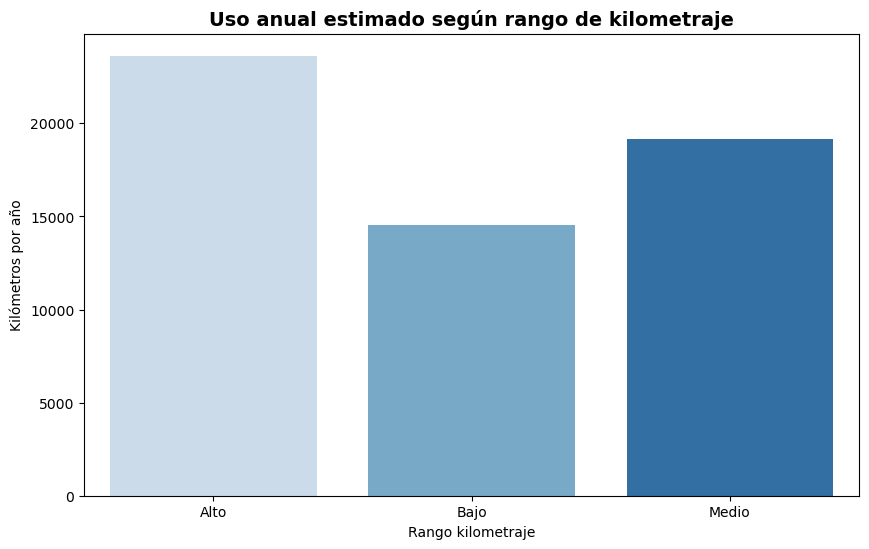

In [46]:
plt.figure(
figsize=(10,6)
)

sns.barplot(

data=kpi4,

x="rango_kilometraje",

y="uso_anual_estimado",

hue="rango_kilometraje",

palette="Blues",

legend=False

)

plt.title(
"Uso anual estimado según rango de kilometraje",
fontsize=14,
fontweight="bold"
)

plt.xlabel(
"Rango kilometraje"
)

plt.ylabel(
"Kilómetros por año"
)

plt.show()

## KPI 4 – Coherencia entre nivel de uso y utilización anual

El análisis permitió evaluar si el nivel de kilometraje observado mantiene coherencia con el uso anual estimado del vehículo.

Los resultados muestran que los vehículos clasificados con kilometraje alto presentan un promedio cercano a 23.629 kilómetros recorridos por año, mientras que los vehículos de kilometraje bajo registran aproximadamente 14.530 kilómetros anuales.

Este comportamiento indica consistencia entre el uso acumulado y el patrón anual estimado de utilización.

Desde una perspectiva táctica, este indicador permite complementar procesos de valorización verificando que el precio estimado sea coherente con el historial de uso del vehículo.

# Conclusión General

El desarrollo de indicadores tácticos permitió construir una visión del mercado orientada a apoyar procesos de estimación del precio de vehículos usados.

Los resultados muestran que el kilometraje continúa siendo una de las variables con mayor impacto sobre el valor comercial, observándose diferencias cercanas al 30,8% entre vehículos con distintos niveles de uso.

Sin embargo, el análisis evidencia que el precio de mercado también está condicionado por factores asociados al fabricante y al tipo de combustible utilizado.

Finalmente, la evaluación del uso anual estimado permitió validar la consistencia del comportamiento observado dentro del conjunto de datos.

En conjunto, los indicadores construidos permiten apoyar procesos de valorización vehicular utilizando evidencia obtenida del mercado y no únicamente criterios subjetivos.